# Hybrid Retrieval + RAG Fusion (LangGraph)

This notebook implements the **retrieval + reflection** section:
- Hybrid retrieval (BM25 + semantic) with metadata filtering
- Optional re-ranking (non‑LLM)
- Reflection (Good LLM) for relevance check
- Retry with RAG fusion if the first pass is not relevant

Other parts of the full agent (routing, generation, persona, chat history) are intentionally **left out**.

## Install dependencies

In [1]:
# Install with compatible versions to avoid dependency conflicts
%pip -q install langgraph rank-bm25 python-dotenv
%pip -q install langchain-core langchain-community langchain-openai langchain-ollama

# Install sentence-transformers and langchain-huggingface with compatible huggingface-hub
%pip -q install "huggingface-hub>=0.33.4,<1.0.0"
%pip -q install "sentence-transformers>=2.2.0,<3.0.0"
%pip -q install "langchain-huggingface>=0.1.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 123.7 MB/s eta 0:00:0000:010:01


## Config (.env + LLM factory)

Create a `.env` file alongside this notebook with two model tiers. You can use **OpenAI**, **Ollama**, or **Hugging Face**.

Example (Hugging Face like the benchmark):
```
LIGHT_LLM_PROVIDER=huggingface
LIGHT_LLM_MODEL=meta-llama/Llama-3.1-8B-Instruct

GOOD_LLM_PROVIDER=huggingface
GOOD_LLM_MODEL=Qwen/Qwen2.5-72B-Instruct

HUGGINGFACEHUB_API_TOKEN=...
HF_PROVIDER=auto
HF_MAX_NEW_TOKENS=1024
HF_TEMPERATURE=0.2
HF_TOP_P=0.95
```

Example (OpenAI + Ollama):
```
LIGHT_LLM_PROVIDER=ollama
LIGHT_LLM_MODEL=llama3.1

GOOD_LLM_PROVIDER=openai
GOOD_LLM_MODEL=gpt-4o-mini
OPENAI_API_KEY=...

OLLAMA_BASE_URL=http://localhost:11434
```

Only the retrieval and reflection steps below use these. If no keys are provided, the notebook falls back to heuristic checks.

In [2]:
from __future__ import annotations

import os
from dataclasses import dataclass

from dotenv import load_dotenv

load_dotenv()


@dataclass
class LLMConfig:
    provider: str
    model: str


class LLMFactory:
    def __init__(self, light: LLMConfig, good: LLMConfig):
        self._light = light
        self._good = good

    def light(self):
        return _build_llm(self._light)

    def good(self):
        return _build_llm(self._good)


def _build_llm(cfg: LLMConfig):
    provider = (cfg.provider or "").lower().strip()
    if provider == "openai":
        try:
            from langchain_openai import ChatOpenAI
        except Exception as exc:
            raise RuntimeError("Install langchain-openai for OpenAI models") from exc

        return ChatOpenAI(model=cfg.model, temperature=0.0)

    if provider == "ollama":
        try:
            from langchain_ollama import ChatOllama
        except Exception as exc:
            raise RuntimeError("Install langchain-ollama for Ollama models") from exc

        base_url = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434")
        return ChatOllama(model=cfg.model, base_url=base_url, temperature=0.0)

    if provider in {"huggingface", "hf"}:
        try:
            from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
        except Exception as exc:
            raise RuntimeError("Install langchain-huggingface for HF models") from exc

        # Defaults aligned with .env examples (used if not set)
        os.environ.setdefault("HF_PROVIDER", "auto")
        os.environ.setdefault("HF_MAX_NEW_TOKENS", "1024")
        os.environ.setdefault("HF_TEMPERATURE", "0.2")
        os.environ.setdefault("HF_TOP_P", "0.95")
        os.environ.setdefault("HF_TASK", "text-generation")

        hf_provider = os.environ["HF_PROVIDER"]
        hf_max_new_tokens = int(os.environ["HF_MAX_NEW_TOKENS"])
        hf_temperature = float(os.environ["HF_TEMPERATURE"])
        hf_top_p = float(os.environ["HF_TOP_P"])
        hf_task = os.environ["HF_TASK"]

        endpoint = HuggingFaceEndpoint(
            repo_id=cfg.model,
            task=hf_task,
            provider=hf_provider,
            max_new_tokens=hf_max_new_tokens,
            temperature=hf_temperature,
            top_p=hf_top_p,
            return_full_text=False,
        )
        return ChatHuggingFace(llm=endpoint)

    return None


light_cfg = LLMConfig(
    provider=os.environ.get("LIGHT_LLM_PROVIDER", ""),
    model=os.environ.get("LIGHT_LLM_MODEL", ""),
)

good_cfg = LLMConfig(
    provider=os.environ.get("GOOD_LLM_PROVIDER", ""),
    model=os.environ.get("GOOD_LLM_MODEL", ""),
)

factory = LLMFactory(light=light_cfg, good=good_cfg)
light_llm = factory.light()
good_llm = factory.good()

print("Light LLM:", light_llm.model_id)
print("Good LLM:", good_llm.model_id)
if light_llm is None or good_llm is None:
    print("LLM(s) not configured. Heuristic fallback will be used.")

Light LLM: meta-llama/Llama-3.1-8B-Instruct
Good LLM: Qwen/Qwen2.5-72B-Instruct


## Load data (TO BE CHANGED)

In [3]:
from pathlib import Path

# Path to CSV (same as benchmark)
csv_path = Path("fashion.csv")

if not csv_path.exists():
    raise FileNotFoundError("Expected fashion.csv next to this notebook")

print(f"✅ CSV path set: {csv_path}")
print("   (Documents will be loaded via CSVLoader in the indexing step - same as benchmark)")

✅ CSV path set: fashion.csv
   (Documents will be loaded via CSVLoader in the indexing step - same as benchmark)


## Imports & Indexes (same setup as benchmark)

In [4]:
import re
import numpy as np
from typing import Iterable
from rank_bm25 import BM25Okapi
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_community.document_loaders import CSVLoader

# ============================================================
# Preprocessing & Filter Functions
# ============================================================

def preprocess_for_bm25(text: str) -> list[str]:
    """
    BM25 tokenization:
    - Lowercase
    - Remove punctuation
    """
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    # Remove single-character tokens
    tokens = [t for t in tokens if t and len(t) > 1]
    return tokens


def _passes_metadata_filter(metadata: dict, filters: dict | None) -> bool:
    """
    Check if document metadata passes the given filters.
    Used for post-retrieval filtering.
    """
    if not filters:
        return True
    for key, value in filters.items():
        if value is None or value == "":
            continue
        if str(metadata.get(key, "")) != str(value):
            return False
    return True

print("✅ Imports and helper functions loaded")

✅ Imports and helper functions loaded


In [5]:
# ============================================================
# STEP 4: Build Indexes (BM25 + InMemoryVectorStore)
# EXACT SAME SETUP AS BENCHMARK for fair comparison
# ============================================================

EMBED_MODEL_NAME = os.environ.get("EMBED_MODEL_NAME", "sentence-transformers/all-MiniLM-L6-v2")

# Initialize embeddings (SAME as benchmark)
print(f"🔧 Loading embeddings: {EMBED_MODEL_NAME}")
embeddings = HuggingFaceEmbeddings(model_name=EMBED_MODEL_NAME)
print(f"✅ Embeddings loaded (same as benchmark)")

# --- Load documents using CSVLoader (SAME as benchmark) ---
print("\n🔧 Loading documents with CSVLoader (same as benchmark)...")
loader = CSVLoader(file_path=str(csv_path), encoding="utf-8")
langchain_docs = loader.load()
print(f"✅ Loaded {len(langchain_docs)} documents")
print(f"📄 Sample document format:\n{langchain_docs[0].page_content[:300]}...")

# --- ENRICH METADATA: Parse CSV fields from page_content ---
# CSVLoader only stores 'source' and 'row' in metadata by default
# We need Gender, Colour, ProductId etc. for filtering
print("\n🔧 Enriching document metadata from page_content...")

def parse_metadata_from_content(content: str) -> dict:
    """Parse key: value pairs from CSVLoader's page_content format."""
    metadata = {}
    for line in content.split("\n"):
        if ": " in line:
            key, value = line.split(": ", 1)
            metadata[key.strip()] = value.strip()
    return metadata

for doc in langchain_docs:
    parsed = parse_metadata_from_content(doc.page_content)
    doc.metadata.update(parsed)

print(f"✅ Metadata enriched!")
print(f"📋 Sample metadata keys: {list(langchain_docs[0].metadata.keys())}")
print(f"   Gender: {langchain_docs[0].metadata.get('Gender')}")
print(f"   Colour: {langchain_docs[0].metadata.get('Colour')}")
print(f"   ProductId: {langchain_docs[0].metadata.get('ProductId')}")

# --- BM25 Index (using same page_content as semantic) ---
print("\n🔧 Building BM25 index...")
corpus_tokens = [preprocess_for_bm25(doc.page_content) for doc in langchain_docs]
bm25 = BM25Okapi(corpus_tokens)
print(f"✅ BM25 index: {len(corpus_tokens)} documents")
print(f"   Sample tokens: {corpus_tokens[0][:10]}...")

# --- InMemoryVectorStore (SAME as benchmark) ---
print("\n🔧 Building InMemoryVectorStore (same as benchmark)...")
vector_store = InMemoryVectorStore(embeddings)
_ = vector_store.add_documents(documents=langchain_docs)

print(f"✅ InMemoryVectorStore: {len(langchain_docs)} documents")
print(f"\n📊 Indexes ready! (EXACT same setup as benchmark + enriched metadata)")

🔧 Loading embeddings: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embeddings loaded (same as benchmark)

🔧 Loading documents with CSVLoader (same as benchmark)...
✅ Loaded 2906 documents
📄 Sample document format:
ProductId: 42419
Gender: Girls
Category: Apparel
SubCategory: Topwear
ProductType: Tops
Colour: White
Usage: Casual
ProductTitle: Gini and Jony Girls Knit White Top
Image: 42419.jpg
ImageURL: https://assets.myntassets.com/v1/images/style/properties/f3964f76c78edd85f4512d98b26d52e9_images.jpg
Size: L...

🔧 Enriching document metadata from page_content...
✅ Metadata enriched!
📋 Sample metadata keys: ['source', 'row', 'ProductId', 'Gender', 'Category', 'SubCategory', 'ProductType', 'Colour', 'Usage', 'ProductTitle', 'Image', 'ImageURL', 'Size']
   Gender: Girls
   Colour: White
   ProductId: 42419

🔧 Building BM25 index...
✅ BM25 index: 2906 documents
   Sample tokens: ['productid', '42419', 'gender', 'girls', 'category', 'apparel', 'subcategory', 'topwear', 'producttype', 'tops']...

🔧 Building InMemoryVectorStore (same as benchmark)...
✅ In

## Retrieval utilities (hybrid + metadata filtering)

In [6]:
# ============================================================
# STEP 5: Search Functions (same document format as benchmark)
# ============================================================

def bm25_search(query: str, k: int = 10, filters: dict | None = None):
    """
    BM25 lexical search using same documents as benchmark.
    """
    tokens = preprocess_for_bm25(query)

    if not tokens:
        return []

    scores = bm25.get_scores(tokens)
    scored = []

    for idx, score in enumerate(scores):
        doc = langchain_docs[idx]
        metadata = doc.metadata

        # Apply metadata filter
        if not _passes_metadata_filter(metadata, filters):
            continue

        scored.append({
            "id": idx,
            "text": doc.page_content,
            "metadata": metadata,
            "score": float(score),
            "source": "bm25",
        })

    scored.sort(key=lambda x: x["score"], reverse=True)
    return scored[:k]


def semantic_search(query: str, k: int = 10, filters: dict | None = None):
    """
    Semantic (vector) search using InMemoryVectorStore (SAME as benchmark).
    """
    # If filters are applied, retrieve more and filter after
    search_k = k * 5 if filters else k

    # Use similarity_search_with_score (same as benchmark)
    results_with_scores = vector_store.similarity_search_with_score(query, k=search_k)

    results = []
    for doc, score in results_with_scores:
        metadata = doc.metadata

        # Apply metadata filter (post-retrieval)
        if not _passes_metadata_filter(metadata, filters):
            continue

        results.append({
            "id": metadata.get("row", 0),  # CSVLoader adds 'row' to metadata
            "text": doc.page_content,
            "metadata": metadata,
            "score": float(score),
            "source": "semantic",
        })

        if len(results) >= k:
            break

    return results


def _rrf_fuse(result_lists: Iterable[list[dict]], k: int = 10, rrf_k: int = 60):
    """Reciprocal Rank Fusion to combine multiple result lists."""
    fused = {}
    for results in result_lists:
        for rank, item in enumerate(results, start=1):
            doc_id = item["id"]
            fused.setdefault(doc_id, {**item, "rrf_score": 0.0})
            fused[doc_id]["rrf_score"] += 1.0 / (rrf_k + rank)
    merged = list(fused.values())
    merged.sort(key=lambda x: x["rrf_score"], reverse=True)
    return merged[:k]


def hybrid_retrieve(query: str, k: int = 10, filters: dict | None = None):
    """Hybrid retrieval: BM25 + Semantic with RRF fusion."""
    bm25_results = bm25_search(query, k=k, filters=filters)
    semantic_results = semantic_search(query, k=k, filters=filters)
    fused = _rrf_fuse([bm25_results, semantic_results], k=k)
    return fused


def rerank_cross_encoder(query: str, docs: list[dict], enabled: bool = False):
    """Optional cross-encoder re-ranking."""
    if not enabled:
        return docs
    try:
        from sentence_transformers import CrossEncoder
    except Exception:
        print("CrossEncoder not available, skipping rerank")
        return docs

    reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    pairs = [[query, d["text"]] for d in docs]
    scores = reranker.predict(pairs)
    for i, s in enumerate(scores):
        docs[i]["rerank_score"] = float(s)
    docs.sort(key=lambda x: x.get("rerank_score", 0.0), reverse=True)
    return docs

print("✅ Search functions defined (with improved preprocessing)")

# Quick test
print("\n🔍 Quick test: 'white tops girls Gini Jony'")
test_results = bm25_search("white tops girls Gini Jony", k=3)
for r in test_results:
    print(f"   Score: {r['score']:.2f} | {r['metadata'].get('ProductId')} | {r['metadata'].get('ProductTitle', '')[:40]}...")

✅ Search functions defined (with improved preprocessing)

🔍 Quick test: 'white tops girls Gini Jony'
   Score: 9.50 | 31173 | Gini and Jony Girls Printed White Top...
   Score: 9.50 | 45568 | Gini and Jony Girls Knit White Top...
   Score: 9.50 | 31160 | Gini and Jony Girls Printed White Top...


### Inline notes for retrieval utilities

- `_passes_metadata_filter()` applies metadata filters (post-retrieval for both BM25 and semantic).
- `bm25_search()` is lexical search; it returns a list of scored docs.
- `semantic_search()` is vector search using **InMemoryVectorStore** (same as benchmark for fair comparison).
- `_rrf_fuse()` combines rankings using Reciprocal Rank Fusion (RRF).
- `hybrid_retrieve()` runs BM25 + semantic and fuses results.
- `rerank_cross_encoder()` is optional non‑LLM reranking with a cross‑encoder.

## RAG fusion helpers

In [7]:
from langchain_core.messages import HumanMessage


import time
from functools import lru_cache

# Rate limiting settings
_last_llm_call_time = 0
LLM_CALL_DELAY_SECONDS = 1.0  # Delay between LLM calls to avoid rate limits

# Track consecutive failures to switch strategies
_consecutive_failures = 0
_use_heuristic_only = False


def _smart_heuristic_variations(query: str, n: int = 3) -> list[str]:
    """
    Generate smarter heuristic query variations without LLM.
    Better than simple lowercase/remove punctuation.
    """
    base = query.strip()
    variations = [base]

    # Variation 1: Remove filler words
    filler_words = ["do you have", "show me", "i need", "looking for", "any", "please", "can you"]
    simplified = base.lower()
    for filler in filler_words:
        simplified = simplified.replace(filler, "").strip()
    if simplified and simplified != base.lower():
        variations.append(simplified)

    # Variation 2: Extract key terms (nouns, colors, etc.)
    key_terms = [w for w in base.split() if len(w) > 3 and w.lower() not in
                 {"have", "show", "need", "looking", "any", "please", "the", "for", "and", "with"}]
    if key_terms:
        variations.append(" ".join(key_terms))

    # Variation 3: Remove question marks and lowercase
    variations.append(base.replace("?", "").lower())

    # Deduplicate while preserving order
    seen = set()
    unique = []
    for v in variations:
        if v.lower() not in seen:
            seen.add(v.lower())
            unique.append(v)

    return unique[:n]


def generate_query_variations(query: str, llm=None, n: int = 3) -> list[str]:
    """
    Generate query variations for RAG Fusion.
    Features:
    - Rate limiting (delay between calls)
    - Auto-fallback to heuristics after consecutive failures
    - Smart heuristic variations
    """
    global _last_llm_call_time, _consecutive_failures, _use_heuristic_only

    # Smart heuristic fallback
    heuristic_fallback = _smart_heuristic_variations(query, n)

    # If LLM disabled or we've switched to heuristic-only mode
    if llm is None or _use_heuristic_only:
        return heuristic_fallback

    # Rate limiting: wait if we called too recently
    time_since_last = time.time() - _last_llm_call_time
    if time_since_last < LLM_CALL_DELAY_SECONDS:
        sleep_time = LLM_CALL_DELAY_SECONDS - time_since_last
        time.sleep(sleep_time)

    try:
        prompt = (
            "Generate {n} diverse search queries that are paraphrases of the user query. "
            "Return one query per line, no numbering.\n\nUser query: {query}"
        )
        msg = HumanMessage(content=prompt.format(n=n, query=query))

        _last_llm_call_time = time.time()
        resp = llm.invoke([msg])

        lines = [ln.strip() for ln in resp.content.splitlines() if ln.strip()]
        if query not in lines:
            lines.insert(0, query)

        # Reset failure counter on success
        _consecutive_failures = 0
        return lines[:n]

    except Exception as e:
        _consecutive_failures += 1
        error_msg = str(e)[:100]

        # After 3 consecutive failures, switch to heuristic-only mode
        if _consecutive_failures >= 3:
            if not _use_heuristic_only:
                print(f"⚠️ {_consecutive_failures} consecutive LLM failures. Switching to heuristic-only mode.")
                _use_heuristic_only = True
        else:
            print(f"⚠️ LLM failed ({_consecutive_failures}/3): {error_msg}... Using heuristic.")

        return heuristic_fallback


def reset_llm_fallback():
    """Reset the LLM fallback state (call this to re-enable LLM after fixing credits)."""
    global _consecutive_failures, _use_heuristic_only
    _consecutive_failures = 0
    _use_heuristic_only = False
    print("✅ LLM fallback reset. Will attempt LLM calls again.")


def rag_fusion_retrieve(query: str, k: int = 10, filters: dict | None = None, llm=None):
    variations = generate_query_variations(query, llm=llm, n=3)
    all_results = [hybrid_retrieve(q, k=k, filters=filters) for q in variations]
    fused = _rrf_fuse(all_results, k=k)
    return fused, variations

## Reflection / relevance check

In [8]:
def _snippet(text: str, max_chars: int = 300) -> str:
    text = text or ""
    return text if len(text) <= max_chars else (text[: max_chars - 20] + "... [truncated]")


def check_relevance(query: str, docs: list[dict], llm=None, threshold: float = 0.35) -> dict:
    if not docs:
        return {"is_relevant": False, "reason": "no_docs"}

    if llm is None:
        # Heuristic fallback: rely on top fused score
        top_score = docs[0].get("rrf_score", docs[0].get("score", 0.0))
        return {"is_relevant": top_score >= threshold, "reason": f"heuristic_score={top_score:.3f}"}

    context = "\n\n".join(_snippet(d["text"]) for d in docs[:3])
    prompt = (
        "You are verifying whether the retrieved context is relevant to the user query. "
        "Answer with YES or NO, then a short reason.\n\n"
        f"Query: {query}\n\nContext:\n{context}\n"
    )
    msg = HumanMessage(content=prompt)
    resp = llm.invoke([msg]).content.strip()
    is_relevant = resp.upper().startswith("YES")
    return {"is_relevant": is_relevant, "reason": resp}

## LangGraph flow (retrieve → reflect → fuse → reflect)

In [9]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END


class RetrievalState(TypedDict, total=False):
    query: str
    filters: dict
    use_fusion: bool
    fusion_queries: list[str]
    retrieved_docs: list[dict]
    is_relevant: bool
    relevance_reason: str
    final_payload: dict


def retrieve_node(state: RetrievalState) -> RetrievalState:
    query = state["query"]
    filters = state.get("filters")

    if state.get("use_fusion"):
        docs, variations = rag_fusion_retrieve(query, k=10, filters=filters, llm=light_llm)
        state["fusion_queries"] = variations
    else:
        docs = hybrid_retrieve(query, k=10, filters=filters)

    docs = rerank_cross_encoder(query, docs, enabled=False)

    state["retrieved_docs"] = docs
    return state


def reflect_node(state: RetrievalState) -> RetrievalState:
    query = state["query"]
    docs = state.get("retrieved_docs", [])

    result = check_relevance(query, docs, llm=good_llm)
    state["is_relevant"] = result["is_relevant"]
    state["relevance_reason"] = result["reason"]
    return state


def enable_fusion_node(state: RetrievalState) -> RetrievalState:
    state["use_fusion"] = True
    return state


def finalize_node(state: RetrievalState) -> RetrievalState:
    # Placeholder for the generator in the full agent
    if state.get("is_relevant"):
        state["final_payload"] = {
            "status": "ready_for_generation",
            "docs": state.get("retrieved_docs", [])[:5],
        }
    else:
        state["final_payload"] = {
            "status": "no_data",
            "message": "No relevant data found after fusion.",
        }
    return state


def should_fuse(state: RetrievalState) -> str:
    if state.get("is_relevant"):
        return "finalize"
    if not state.get("use_fusion"):
        return "fuse"
    return "finalize"


graph = StateGraph(RetrievalState)

graph.add_node("retrieve", retrieve_node)
graph.add_node("reflect", reflect_node)
graph.add_node("enable_fusion", enable_fusion_node)
graph.add_node("finalize", finalize_node)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "reflect")

graph.add_conditional_edges(
    "reflect",
    should_fuse,
    {
        "fuse": "enable_fusion",
        "finalize": "finalize",
    },
)

graph.add_edge("enable_fusion", "retrieve")
graph.add_edge("finalize", END)

retrieval_graph = graph.compile()
print(retrieval_graph)

## Example run

In [10]:
query = "Do you have a pink top for girls from Gini and Jony?"
filters = {
    "Gender": "Girls",
    "Colour": "Pink",
}

result = retrieval_graph.invoke({
    "query": query,
    "filters": filters,
    "use_fusion": False,
})

print("Relevance:", result.get("is_relevant"), result.get("relevance_reason"))
print("Fusion queries:", result.get("fusion_queries"))
print("Final payload status:", result.get("final_payload", {}).get("status"))

# Show top retrieved docs with FULL metadata
print("\n" + "=" * 60)
print("RETRIEVED DOCUMENTS (Full Data)")
print("=" * 60)

for i, d in enumerate((result.get("retrieved_docs") or [])[:5], 1):
    print(f"\n📄 Document {i}")
    print(f"   ID: {d.get('id')}")
    print(f"   Text: {d.get('text')}")
    print(f"   Score: {d.get('rrf_score', d.get('score', 'N/A')):.4f}")
    print(f"   Source: {d.get('source', 'hybrid')}")
    print(f"   Metadata:")
    for key, value in d.get("metadata", {}).items():
        print(f"      - {key}: {value}")

Relevance: True YES. The context provides information about pink tops for girls, including products from the brand Gini and Jony, which directly matches the user's query.
Fusion queries: None
Final payload status: ready_for_generation

RETRIEVED DOCUMENTS (Full Data)

📄 Document 1
   ID: 508
   Text: ProductId: 40993
Gender: Girls
Category: Apparel
SubCategory: Topwear
ProductType: Tops
Colour: Pink
Usage: Casual
ProductTitle: Gini and Jony Girls Pink Striped Top
Image: 40993.jpg
ImageURL: https://assets.myntassets.com/assets/images/40993/2018/3/14/11521029937692-Gini-and-Jony-Girls-Woven-Pink-Tops-7341521029937469-1.jpg
Size: X-Large, Medium, Large
   Score: 0.0308
   Source: bm25
   Metadata:
      - source: fashion.csv
      - row: 508
      - ProductId: 40993
      - Gender: Girls
      - Category: Apparel
      - SubCategory: Topwear
      - ProductType: Tops
      - Colour: Pink
      - Usage: Casual
      - ProductTitle: Gini and Jony Girls Pink Striped Top
      - Image: 40993.

## Retrieval Evaluation

This section allows you to evaluate retrieval quality and compare different strategies:
- **Hybrid Retrieval** (BM25 + Semantic)
- **RAG Fusion** (Multi-query + RRF)
- **With/Without Re-ranking**

Metrics computed:
- **Recall@k**: Did we retrieve the relevant document?
- **Precision@k**: How many retrieved docs are relevant?
- **MRR**: Mean Reciprocal Rank (quality of top result)
- **MAP**: Mean Average Precision (ranking quality)
- **NDCG**: Normalized Discounted Cumulative Gain

In [19]:
### Load Evaluation Queries (NEW FORMAT)

import ast
import json
import pandas as pd
from pathlib import Path

def load_evaluation_queries(csv_path: str = "/retrieval_eval_ground_truth.csv", use_filters: bool = True):
    """
    Load evaluation queries from CSV file (NEW FORMAT).

    Expected CSV columns:
    - query: The user query
    - ground_truth_product_ids: Comma-separated ProductIds (e.g., "42419,34009")
    - difficulty: easy|medium|hard
    - query_type: specific|broad|recommendation|availability
    - expected_filters: JSON string (e.g., '{"Gender":"Girls","Colour":"Pink"}')
    - notes: Explanation

    Args:
        csv_path: Path to the evaluation CSV
        use_filters: If True, use expected_filters from CSV. If False, no filters.
    """
    csv_file = Path(csv_path)
    if not csv_file.exists():
        print(f"⚠️ {csv_path} not found. Using default test queries.")
        return [
            {
                "query": "Do you have pink tops for girls?",
                "ground_truth_product_ids": ["23623", "31120"],
                "difficulty": "easy",
                "query_type": "specific",
                "filters": {"Gender": "Girls", "Colour": "Pink"} if use_filters else {},
                "notes": "Default test query"
            },
        ]

    df_eval = pd.read_csv(csv_file)
    eval_queries = []

    for _, row in df_eval.iterrows():
        # Parse ground_truth_product_ids (comma-separated string)
        gt_ids_str = str(row.get("ground_truth_product_ids", ""))
        if gt_ids_str and gt_ids_str.lower() != "nan":
            product_ids = [pid.strip() for pid in gt_ids_str.split(",") if pid.strip()]
        else:
            product_ids = []  # Negative case - no matching products

        # Parse expected_filters (JSON string)
        # ONLY use fields that support exact matching (not ProductTitle, Size, etc.)
        ALLOWED_FILTER_FIELDS = {"Gender", "Colour", "Category", "ProductType", "SubCategory", "Usage"}

        filters = {}
        if use_filters:
            filters_str = row.get("expected_filters", "{}")
            if pd.notna(filters_str) and filters_str:
                try:
                    filters_str = str(filters_str).replace('""', '"')
                    all_filters = json.loads(filters_str)
                except json.JSONDecodeError:
                    try:
                        all_filters = ast.literal_eval(filters_str)
                    except:
                        all_filters = {}

                # Only keep allowed filter fields (exact match fields)
                filters = {k: v for k, v in all_filters.items() if k in ALLOWED_FILTER_FIELDS}

        eval_queries.append({
            "query": row["query"],
            "ground_truth_product_ids": product_ids,
            "difficulty": row.get("difficulty", "medium"),
            "query_type": row.get("query_type", "specific"),
            "filters": filters,
            "notes": row.get("notes", ""),
        })

    filter_status = "WITH filters" if use_filters else "WITHOUT filters"
    print(f"✅ Loaded {len(eval_queries)} evaluation queries {filter_status}")

    # Show difficulty distribution
    difficulties = [q.get("difficulty", "medium") for q in eval_queries]
    print(f"   Difficulty: {difficulties.count('easy')} easy, {difficulties.count('medium')} medium, {difficulties.count('hard')} hard")

    # Count negative cases
    negative_cases = sum(1 for q in eval_queries if not q["ground_truth_product_ids"])
    if negative_cases:
        print(f"   Negative cases (no match expected): {negative_cases}")

    return eval_queries

# Load evaluation queries WITH filters
eval_queries = load_evaluation_queries(use_filters=True)
if eval_queries:
    print(f"\n📋 Sample query:")
    print(f"   Query: {eval_queries[0]['query']}")
    print(f"   Expected ProductIds: {eval_queries[0]['ground_truth_product_ids']}")
    print(f"   Difficulty: {eval_queries[0].get('difficulty', 'N/A')}")
    print(f"   Filters: {eval_queries[0]['filters']}")

# Also load WITHOUT filters for comparison
eval_queries_no_filter = load_evaluation_queries(use_filters=False)
print(f"\n(Also loaded {len(eval_queries_no_filter)} queries without filters for comparison)")

✅ Loaded 40 evaluation queries WITH filters
   Difficulty: 24 easy, 12 medium, 4 hard
   Negative cases (no match expected): 4

📋 Sample query:
   Query: Show me women's black sports shoes
   Expected ProductIds: ['34651']
   Difficulty: easy
   Filters: {'Gender': 'Women', 'Category': 'Footwear', 'ProductType': 'Sports Shoes', 'Colour': 'Black'}
✅ Loaded 40 evaluation queries WITHOUT filters
   Difficulty: 24 easy, 12 medium, 4 hard
   Negative cases (no match expected): 4

(Also loaded 40 queries without filters for comparison)


In [20]:
### Evaluation Metrics Utilities

import numpy as np
from typing import Callable

def calculate_retrieval_metrics(
    retrieved_docs: list[dict],
    ground_truth_ids: list[str],
    k: int = 10
) -> dict:
    """
    Calculate standard retrieval metrics.

    Args:
        retrieved_docs: List of retrieved documents with 'id' and 'metadata' fields
        ground_truth_ids: List of expected ProductIds (as strings)
        k: Number of top results to consider

    Returns:
        Dictionary of metrics
    """
    # Get retrieved ProductIds
    retrieved_ids = []
    for doc in retrieved_docs[:k]:
        # Try to get ProductId from metadata or id
        product_id = str(doc.get("metadata", {}).get("ProductId", doc.get("id", "")))
        retrieved_ids.append(product_id)

    # Convert ground truth to set for fast lookup
    gt_set = set(str(pid) for pid in ground_truth_ids)

    # Hit@k: Did we retrieve at least one relevant document?
    hits = [1 if rid in gt_set else 0 for rid in retrieved_ids]
    hit_at_k = 1.0 if any(hits) else 0.0

    # Recall@k: Proportion of ground truth docs retrieved
    retrieved_relevant = len(set(retrieved_ids) & gt_set)
    recall_at_k = retrieved_relevant / len(gt_set) if gt_set else 0.0

    # Precision@k: Proportion of retrieved docs that are relevant
    precision_at_k = retrieved_relevant / len(retrieved_ids) if retrieved_ids else 0.0

    # MRR: Reciprocal Rank of first relevant document
    mrr = 0.0
    for i, rid in enumerate(retrieved_ids, 1):
        if rid in gt_set:
            mrr = 1.0 / i
            break

    # MAP: Mean Average Precision
    relevant_count = 0
    precision_sum = 0.0
    for i, rid in enumerate(retrieved_ids, 1):
        if rid in gt_set:
            relevant_count += 1
            precision_sum += relevant_count / i
    map_score = precision_sum / len(gt_set) if gt_set else 0.0

    # NDCG@k: Normalized Discounted Cumulative Gain
    dcg = 0.0
    for i, rid in enumerate(retrieved_ids, 1):
        if rid in gt_set:
            dcg += 1.0 / np.log2(i + 1)

    # Ideal DCG (all relevant docs at top)
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(gt_set), k) + 1))
    ndcg_at_k = dcg / idcg if idcg > 0 else 0.0

    return {
        "hit@k": hit_at_k,
        "recall@k": recall_at_k,
        "precision@k": precision_at_k,
        "mrr": mrr,
        "map": map_score,
        "ndcg@k": ndcg_at_k,
        "retrieved_ids": retrieved_ids,
        "ground_truth_ids": list(gt_set),
        "num_retrieved": len(retrieved_ids),
        "num_relevant_retrieved": retrieved_relevant,
    }


def evaluate_retrieval_strategy(
    retrieval_fn: Callable,
    eval_queries: list[dict],
    k: int = 5,
    strategy_name: str = "Strategy"
) -> pd.DataFrame:
    """
    Evaluate a retrieval strategy on all evaluation queries.

    Args:
        retrieval_fn: Function that takes (query, k, filters) and returns list of docs
        eval_queries: List of evaluation query dictionaries
        k: Number of results to retrieve
        strategy_name: Name of the strategy for display

    Returns:
        DataFrame with per-query and aggregate metrics
    """
    results = []

    print(f"\n{'='*60}")
    print(f"Evaluating: {strategy_name} (k={k})")
    print(f"{'='*60}")

    for i, eq in enumerate(eval_queries, 1):
        query = eq["query"]
        gt_ids = eq["ground_truth_product_ids"]
        filters = eq.get("filters", {})
        difficulty = eq.get("difficulty", "medium")
        query_type = eq.get("query_type", "specific")

        # Run retrieval
        try:
            docs = retrieval_fn(query, k=k, filters=filters if filters else None)
            metrics = calculate_retrieval_metrics(docs, gt_ids, k=k)
            metrics["query"] = query[:50] + "..." if len(query) > 50 else query
            metrics["strategy"] = strategy_name
            metrics["difficulty"] = difficulty
            metrics["query_type"] = query_type
            results.append(metrics)

            status = "✅" if metrics["hit@k"] > 0 else "❌"
            diff_tag = f"[{difficulty}]" if difficulty else ""
            print(f"{status} Query {i}/{len(eval_queries)} {diff_tag}: MRR={metrics['mrr']:.2f}, Recall={metrics['recall@k']:.2f}")
        except Exception as e:
            print(f"❌ Query {i} failed: {e}")
            results.append({
                "query": query[:50],
                "strategy": strategy_name,
                "difficulty": difficulty,
                "query_type": query_type,
                "hit@k": 0, "recall@k": 0, "precision@k": 0,
                "mrr": 0, "map": 0, "ndcg@k": 0, "error": str(e)
            })

    df = pd.DataFrame(results)
    return df


def print_evaluation_summary(df: pd.DataFrame, strategy_name: str = "Strategy"):
    """Print aggregate metrics summary"""
    print(f"\n{'='*60}")
    print(f"📊 {strategy_name} - EVALUATION SUMMARY")
    print(f"{'='*60}")
    print(f"\nTotal Queries: {len(df)}")
    print(f"\n🎯 Retrieval Metrics (averaged):")
    print(f"  • Hit@k:       {df['hit@k'].mean():.3f}  (found at least 1 relevant)")
    print(f"  • Recall@k:    {df['recall@k'].mean():.3f}  (completeness)")
    print(f"  • Precision@k: {df['precision@k'].mean():.3f}  (accuracy)")
    print(f"  • MRR:         {df['mrr'].mean():.3f}  (first relevant rank)")
    print(f"  • MAP:         {df['map'].mean():.3f}  (ranking quality)")
    print(f"  • NDCG@k:      {df['ndcg@k'].mean():.3f}  (graded relevance)")
    print(f"\n✅ Success Rate: {df['hit@k'].mean()*100:.1f}%")
    print(f"{'='*60}")

print("✅ Evaluation utilities loaded")

✅ Evaluation utilities loaded


In [ ]:
### Run Evaluation - Compare Retrieval Strategies

# ============================================================
# DEFINE ALL RETRIEVAL STRATEGIES
# ============================================================

# --- Basic Strategies ---
def bm25_only(query, k=5, filters=None):
    """BM25 lexical search only"""
    return bm25_search(query, k=k, filters=filters)

def semantic_only(query, k=5, filters=None):
    """Semantic search only"""
    return semantic_search(query, k=k, filters=filters)

def hybrid_rrf(query, k=5, filters=None):
    """Hybrid (BM25 + Semantic) with RRF fusion"""
    return hybrid_retrieve(query, k=k, filters=filters)

# --- Weighted Hybrid (adjustable weights) ---
def hybrid_weighted(query, k=5, filters=None, bm25_weight=0.3, semantic_weight=0.7):
    """Hybrid with weighted score combination instead of RRF"""
    bm25_results = bm25_search(query, k=k*2, filters=filters)
    semantic_results = semantic_search(query, k=k*2, filters=filters)

    # Normalize scores to 0-1 range
    if bm25_results:
        max_bm25 = max(r["score"] for r in bm25_results) or 1
        for r in bm25_results:
            r["norm_score"] = r["score"] / max_bm25

    if semantic_results:
        max_sem = max(r["score"] for r in semantic_results) or 1
        for r in semantic_results:
            r["norm_score"] = r["score"] / max_sem

    # Combine scores
    combined = {}
    for r in bm25_results:
        combined[r["id"]] = {**r, "final_score": r["norm_score"] * bm25_weight}

    for r in semantic_results:
        if r["id"] in combined:
            combined[r["id"]]["final_score"] += r["norm_score"] * semantic_weight
        else:
            combined[r["id"]] = {**r, "final_score": r["norm_score"] * semantic_weight}

    results = sorted(combined.values(), key=lambda x: x["final_score"], reverse=True)
    return results[:k]

def hybrid_bm25_heavy(query, k=5, filters=None):
    """Hybrid weighted 70% BM25 + 30% Semantic"""
    return hybrid_weighted(query, k=k, filters=filters, bm25_weight=0.7, semantic_weight=0.3)

def hybrid_semantic_heavy(query, k=5, filters=None):
    """Hybrid weighted 30% BM25 + 70% Semantic"""
    return hybrid_weighted(query, k=k, filters=filters, bm25_weight=0.3, semantic_weight=0.7)

def hybrid_balanced(query, k=5, filters=None):
    """Hybrid weighted 50% BM25 + 50% Semantic"""
    return hybrid_weighted(query, k=k, filters=filters, bm25_weight=0.5, semantic_weight=0.5)

# --- Re-ranking Strategies ---
def semantic_with_rerank(query, k=5, filters=None):
    """Semantic search + Cross-encoder re-ranking"""
    docs = semantic_search(query, k=k*3, filters=filters)
    return rerank_cross_encoder(query, docs, enabled=True)[:k]

def hybrid_with_rerank(query, k=5, filters=None):
    """Hybrid + Cross-encoder re-ranking"""
    docs = hybrid_retrieve(query, k=k*3, filters=filters)
    return rerank_cross_encoder(query, docs, enabled=True)[:k]

# --- RAG Fusion ---
def rag_fusion_retrieval(query, k=5, filters=None):
    """RAG Fusion (multi-query + RRF)"""
    docs, _ = rag_fusion_retrieve(query, k=k, filters=filters, llm=light_llm)
    return docs

# --- Larger K retrieval ---
def hybrid_k10(query, k=5, filters=None):
    """Hybrid with larger initial retrieval (k=10), return top 5"""
    docs = hybrid_retrieve(query, k=10, filters=filters)
    return docs[:k]

# ============================================================
# SELECT STRATEGIES TO EVALUATE
# ============================================================

# Choose which strategies to test (comment/uncomment as needed)
STRATEGIES_TO_TEST = {
    # Basic (always test)
    "BM25 Only": bm25_only,
    "Semantic Only": semantic_only,
    "Hybrid (RRF)": hybrid_rrf,

    # Weighted combinations
    "Hybrid (BM25 70%)": hybrid_bm25_heavy,
    "Hybrid (Balanced 50/50)": hybrid_balanced,
    "Hybrid (Semantic 70%)": hybrid_semantic_heavy,

    # Re-ranking (requires CrossEncoder - may be slow)
    # "Semantic + Rerank": semantic_with_rerank,
    # "Hybrid + Rerank": hybrid_with_rerank,

    # Multi-query
    "RAG Fusion": rag_fusion_retrieval,
}

# Evaluation settings
EVAL_K = 5  # Number of results to retrieve

# ============================================================
# RUN EVALUATION
# ============================================================

all_results = []

for strategy_name, strategy_fn in STRATEGIES_TO_TEST.items():
    df = evaluate_retrieval_strategy(strategy_fn, eval_queries, k=EVAL_K, strategy_name=strategy_name)
    all_results.append(df)

print(f"\n✅ Evaluation complete for {len(STRATEGIES_TO_TEST)} strategies!")


Evaluating: BM25 Only (k=5)
❌ Query 1/40 [easy]: MRR=0.00, Recall=0.00
✅ Query 2/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 3/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 4/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 5/40 [easy]: MRR=0.50, Recall=1.00
✅ Query 6/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 7/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 8/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 9/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 10/40 [easy]: MRR=1.00, Recall=1.00
❌ Query 11/40 [easy]: MRR=0.00, Recall=0.00
✅ Query 12/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 13/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 14/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 15/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 16/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 17/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 18/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 19/40 [easy]: MRR=1.00, Recall=1.00
✅ Query 20/40 [easy]: MRR=1.00, Recall=1.00
❌ Query 21/40 [medium]: MRR=0.00, Recall=0.00
✅ Query 22/40 [medium]: MRR=1.00, Recall=1.00
✅ Query 

In [25]:
### Comparison Table - All Strategies

# Combine all results
df_all = pd.concat(all_results, ignore_index=True)

# Create comparison summary
comparison = df_all.groupby("strategy").agg({
    "hit@k": "mean",
    "recall@k": "mean",
    "precision@k": "mean",
    "mrr": "mean",
    "map": "mean",
    "ndcg@k": "mean",
}).round(3)

# Sort by MRR (or your preferred metric)
comparison = comparison.sort_values("mrr", ascending=False)

print("\n" + "=" * 80)
print("📊 RETRIEVAL STRATEGY COMPARISON")
print("=" * 80)
print(f"\nEvaluation: {len(eval_queries)} queries, k={EVAL_K}")
print(f"Strategies tested: {len(comparison)}")
print("\n")

# Display comparison table
display(comparison)

# Find best strategy for each metric
print("\n🏆 Best Strategy per Metric:")
for col in ["hit@k", "recall@k", "precision@k", "mrr", "map", "ndcg@k"]:
    best = comparison[col].idxmax()
    best_val = comparison.loc[best, col]
    print(f"  • {col:12s}: {best} ({best_val:.3f})")

# Overall winner
best_mrr = comparison["mrr"].idxmax()
best_recall = comparison["recall@k"].idxmax()
print(f"\n🥇 RECOMMENDED: {best_mrr} (highest MRR: {comparison.loc[best_mrr, 'mrr']:.3f})")

# Category analysis
print("\n" + "=" * 80)
print("📈 STRATEGY CATEGORY ANALYSIS")
print("=" * 80)

# Group by strategy type
bm25_strategies = [s for s in comparison.index if "BM25" in s and "Hybrid" not in s]
semantic_strategies = [s for s in comparison.index if "Semantic" in s and "Hybrid" not in s]
hybrid_strategies = [s for s in comparison.index if "Hybrid" in s]
fusion_strategies = [s for s in comparison.index if "Fusion" in s]

categories = [
    ("BM25-based", bm25_strategies),
    ("Semantic-based", semantic_strategies),
    ("Hybrid", hybrid_strategies),
    ("Multi-query (Fusion)", fusion_strategies),
]

for cat_name, strategies in categories:
    if strategies:
        cat_df = comparison.loc[strategies]
        avg_mrr = cat_df["mrr"].mean()
        avg_recall = cat_df["recall@k"].mean()
        best_in_cat = cat_df["mrr"].idxmax()
        print(f"\n{cat_name}:")
        print(f"  Avg MRR: {avg_mrr:.3f} | Avg Recall: {avg_recall:.3f}")
        print(f"  Best: {best_in_cat} (MRR: {cat_df.loc[best_in_cat, 'mrr']:.3f})")

# Calculate improvement from baseline (BM25)
print("\n📈 Improvement over BM25 Baseline:")
if "BM25 Only" in comparison.index:
    baseline = comparison.loc["BM25 Only"]
    for strategy in comparison.index:
        if strategy != "BM25 Only":
            mrr_diff = comparison.loc[strategy, "mrr"] - baseline["mrr"]
            recall_diff = comparison.loc[strategy, "recall@k"] - baseline["recall@k"]
            print(f"  • {strategy}: MRR {mrr_diff:+.3f}, Recall {recall_diff:+.3f}")

# Breakdown by difficulty level
if "difficulty" in df_all.columns:
    print("\n📊 Performance by Difficulty Level:")
    for difficulty in ["easy", "medium", "hard"]:
        diff_df = df_all[df_all["difficulty"] == difficulty]
        if len(diff_df) > 0:
            diff_comparison = diff_df.groupby("strategy").agg({"hit@k": "mean", "mrr": "mean"}).round(3)
            print(f"\n  [{difficulty.upper()}] ({len(diff_df)//len(comparison)} queries)")
            for strategy in diff_comparison.index:
                hit = diff_comparison.loc[strategy, "hit@k"]
                mrr = diff_comparison.loc[strategy, "mrr"]
                print(f"    • {strategy}: Hit={hit:.1%}, MRR={mrr:.3f}")


📊 RETRIEVAL STRATEGY COMPARISON

Evaluation: 40 queries, k=5
Strategies tested: 7




,hit@k,recall@k,precision@k,mrr,map,ndcg@k
strategy,,,,,,
Hybrid (RRF),0.725,0.685,0.427,0.694,0.669,0.687
BM25 Only,0.700,0.680,0.422,0.688,0.668,0.684
RAG Fusion,0.700,0.680,0.422,0.671,0.662,0.676
Hybrid (Semantic 70%),0.750,0.687,0.427,0.663,0.631,0.659
Hybrid (Balanced 50/50),0.750,0.689,0.432,0.661,0.632,0.663
Hybrid (BM25 70%),0.700,0.680,0.422,0.650,0.630,0.656
Semantic Only,0.725,0.664,0.426,0.622,0.587,0.623



🏆 Best Strategy per Metric:
  • hit@k       : Hybrid (Semantic 70%) (0.750)
  • recall@k    : Hybrid (Balanced 50/50) (0.689)
  • precision@k : Hybrid (Balanced 50/50) (0.432)
  • mrr         : Hybrid (RRF) (0.694)
  • map         : Hybrid (RRF) (0.669)
  • ndcg@k      : Hybrid (RRF) (0.687)

🥇 RECOMMENDED: Hybrid (RRF) (highest MRR: 0.694)

📈 STRATEGY CATEGORY ANALYSIS

BM25-based:
  Avg MRR: 0.688 | Avg Recall: 0.680
  Best: BM25 Only (MRR: 0.688)

Semantic-based:
  Avg MRR: 0.622 | Avg Recall: 0.664
  Best: Semantic Only (MRR: 0.622)

Hybrid:
  Avg MRR: 0.667 | Avg Recall: 0.685
  Best: Hybrid (RRF) (MRR: 0.694)

Multi-query (Fusion):
  Avg MRR: 0.671 | Avg Recall: 0.680
  Best: RAG Fusion (MRR: 0.671)

📈 Improvement over BM25 Baseline:
  • Hybrid (RRF): MRR +0.006, Recall +0.005
  • RAG Fusion: MRR -0.017, Recall +0.000
  • Hybrid (Semantic 70%): MRR -0.025, Recall +0.007
  • Hybrid (Balanced 50/50): MRR -0.027, Recall +0.009
  • Hybrid (BM25 70%): MRR -0.038, Recall +0.000
  • Se

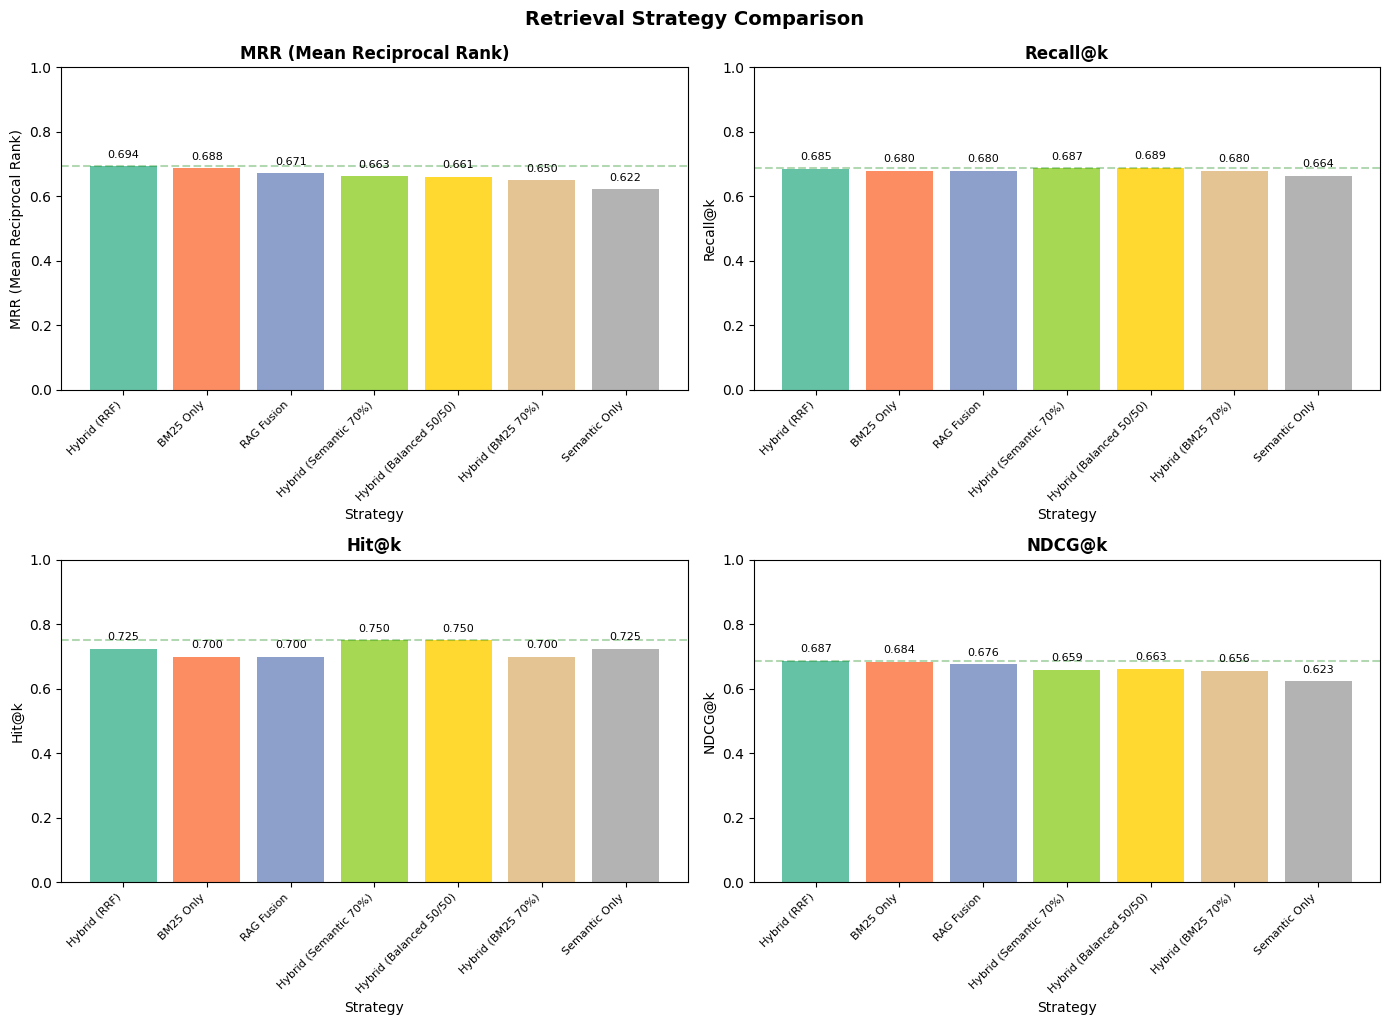

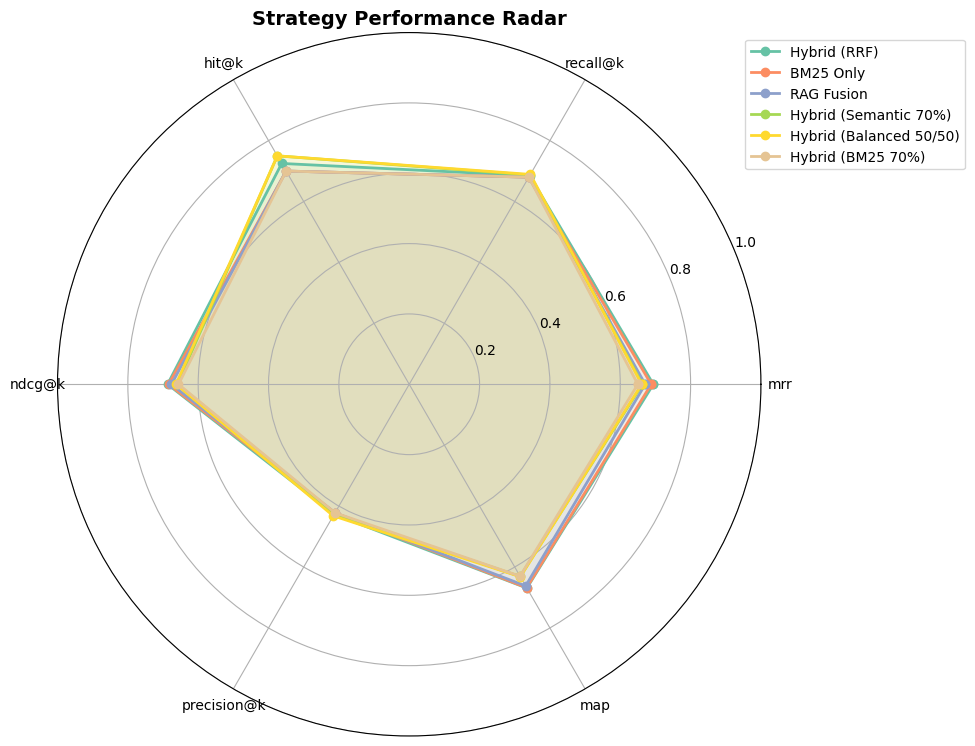


✅ Visualization complete!


In [26]:
### Visualization - Strategy Comparison

import matplotlib.pyplot as plt
import numpy as np

# Create comparison bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Metrics to plot
metrics_to_plot = [
    ("MRR (Mean Reciprocal Rank)", "mrr"),
    ("Recall@k", "recall@k"),
    ("Hit@k", "hit@k"),
    ("NDCG@k", "ndcg@k"),
]

strategies = comparison.index.tolist()
colors = plt.cm.Set2(np.linspace(0, 1, len(strategies)))

for ax, (title, metric) in zip(axes.flatten(), metrics_to_plot):
    values = comparison[metric].values
    bars = ax.bar(range(len(strategies)), values, color=colors)
    ax.set_xlabel("Strategy", fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(strategies)))
    ax.set_xticklabels(strategies, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.axhline(y=values.max(), color='green', linestyle='--', alpha=0.3)

    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.suptitle('Retrieval Strategy Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Radar chart for comprehensive view (if more than 2 strategies)
if len(strategies) >= 3:
    from math import pi

    # Select key metrics
    radar_metrics = ["mrr", "recall@k", "hit@k", "ndcg@k", "precision@k", "map"]

    # Number of variables
    N = len(radar_metrics)

    # Angle for each metric
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # complete the circle

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    for i, strategy in enumerate(strategies[:6]):  # Max 6 strategies for readability
        values = comparison.loc[strategy, radar_metrics].values.tolist()
        values += values[:1]  # complete the circle
        ax.plot(angles, values, 'o-', linewidth=2, label=strategy, color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
    plt.title('Strategy Performance Radar', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n✅ Visualization complete!")

In [23]:
### Detailed Per-Query Results

def show_detailed_results(df: pd.DataFrame, strategy_name: str):
    """Show detailed results for a specific strategy"""
    strategy_df = df[df["strategy"] == strategy_name].copy()

    print(f"\n{'='*70}")
    print(f"📋 Detailed Results: {strategy_name}")
    print(f"{'='*70}")

    for i, row in strategy_df.iterrows():
        status = "✅" if row["hit@k"] > 0 else "❌"
        difficulty = row.get('difficulty', 'N/A')
        query_type = row.get('query_type', 'N/A')
        print(f"\n{status} [{difficulty}] Query: {row['query']}")
        print(f"   Type: {query_type}")
        print(f"   Expected: {row.get('ground_truth_ids', 'N/A')}")
        print(f"   Retrieved: {row.get('retrieved_ids', 'N/A')[:5]}")
        print(f"   Metrics: MRR={row['mrr']:.2f}, Recall={row['recall@k']:.2f}, Precision={row['precision@k']:.2f}")

# Show detailed results for best and baseline strategies
best_strategy = comparison.index[0]  # Best by MRR
print_evaluation_summary(df_all[df_all["strategy"] == best_strategy], best_strategy)
show_detailed_results(df_all, best_strategy)

# Also show BM25 baseline for comparison
if "BM25 Only" in comparison.index and best_strategy != "BM25 Only":
    print("\n\n" + "="*70)
    print("📋 Baseline Comparison (BM25 Only)")
    print("="*70)
    show_detailed_results(df_all, "BM25 Only")


📊 Hybrid (BM25+Semantic) - EVALUATION SUMMARY

Total Queries: 40

🎯 Retrieval Metrics (averaged):
  • Hit@k:       0.725  (found at least 1 relevant)
  • Recall@k:    0.685  (completeness)
  • Precision@k: 0.427  (accuracy)
  • MRR:         0.694  (first relevant rank)
  • MAP:         0.669  (ranking quality)
  • NDCG@k:      0.687  (graded relevance)

✅ Success Rate: 72.5%

📋 Detailed Results: Hybrid (BM25+Semantic)

❌ [easy] Query: Show me women's black sports shoes
   Type: specific
   Expected: ['34651']
   Retrieved: ['9119', '42027', '36417', '42995', '25464']
   Metrics: MRR=0.00, Recall=0.00, Precision=0.00

✅ [easy] Query: Is the Nike Women Free Run pink sports shoe availa...
   Type: availability
   Expected: ['36137']
   Retrieved: ['36137', '6643', '36418', '32190', '40483']
   Metrics: MRR=1.00, Recall=1.00, Precision=0.20

✅ [easy] Query: Do you have ADIDAS women Ranger navy blue sports s...
   Type: specific
   Expected: ['34834']
   Retrieved: ['34834']
   Metrics: MR

In [16]:
### Quick Evaluation Function

def quick_evaluate(
    retrieval_fn: Callable,
    strategy_name: str = "Custom Strategy",
    k: int = 5,
    show_details: bool = True
):
    """
    Quick evaluation function to test any retrieval strategy.

    Usage:
        # Define your custom retrieval function
        def my_custom_retrieval(query, k=5, filters=None):
            # Your custom logic here
            return hybrid_retrieve(query, k=k, filters=filters)

        # Evaluate it
        quick_evaluate(my_custom_retrieval, "My Custom Strategy")
    """
    df = evaluate_retrieval_strategy(retrieval_fn, eval_queries, k=k, strategy_name=strategy_name)
    print_evaluation_summary(df, strategy_name)

    if show_details:
        show_detailed_results(df, strategy_name)

    return df

# Example: Quick test of hybrid retrieval
print("="*70)
print("🚀 Quick Evaluate Example - Run this to test your changes:")
print("="*70)
print("""
# Example usage:

# 1. Define your custom retrieval function:
def my_improved_retrieval(query, k=5, filters=None):
    # Add your improvements here
    docs = hybrid_retrieve(query, k=k*2, filters=filters)
    # Maybe add some post-processing
    return docs[:k]

# 2. Run evaluation:
results = quick_evaluate(my_improved_retrieval, "My Improved Version", k=5)

# 3. Compare with baseline:
# The comparison table above shows how different strategies perform
""")

🚀 Quick Evaluate Example - Run this to test your changes:

# Example usage:

# 1. Define your custom retrieval function:
def my_improved_retrieval(query, k=5, filters=None):
    # Add your improvements here
    docs = hybrid_retrieve(query, k=k*2, filters=filters)
    # Maybe add some post-processing
    return docs[:k]

# 2. Run evaluation:
results = quick_evaluate(my_improved_retrieval, "My Improved Version", k=5)

# 3. Compare with baseline:
# The comparison table above shows how different strategies perform



In [ ]:
### Optional: Evaluate with Re-ranking (requires CrossEncoder)

# Set to True to run re-ranking evaluation (downloads ~100MB model on first run)
RUN_RERANKING_EVAL = False

if RUN_RERANKING_EVAL:
    print("="*60)
    print("🔄 TESTING RE-RANKING STRATEGIES")
    print("="*60)
    print("Note: First run downloads cross-encoder model (~100MB)")

    # Semantic + Re-ranking
    def semantic_reranked(query, k=5, filters=None):
        docs = semantic_search(query, k=k*3, filters=filters)
        return rerank_cross_encoder(query, docs, enabled=True)[:k]

    # Hybrid + Re-ranking
    def hybrid_reranked(query, k=5, filters=None):
        docs = hybrid_retrieve(query, k=k*3, filters=filters)
        return rerank_cross_encoder(query, docs, enabled=True)[:k]

    # BM25 + Re-ranking
    def bm25_reranked(query, k=5, filters=None):
        docs = bm25_search(query, k=k*3, filters=filters)
        return rerank_cross_encoder(query, docs, enabled=True)[:k]

    rerank_strategies = {
        "BM25 + Rerank": bm25_reranked,
        "Semantic + Rerank": semantic_reranked,
        "Hybrid + Rerank": hybrid_reranked,
    }

    rerank_results = []
    for name, fn in rerank_strategies.items():
        df = evaluate_retrieval_strategy(fn, eval_queries, k=EVAL_K, strategy_name=name)
        rerank_results.append(df)

    # Combine with main results
    df_all_with_rerank = pd.concat([df_all] + rerank_results, ignore_index=True)

    # Create updated comparison
    comparison_with_rerank = df_all_with_rerank.groupby("strategy").agg({
        "hit@k": "mean",
        "recall@k": "mean",
        "precision@k": "mean",
        "mrr": "mean",
        "map": "mean",
        "ndcg@k": "mean",
    }).round(3).sort_values("mrr", ascending=False)

    print("\n" + "="*80)
    print("📊 COMPARISON INCLUDING RE-RANKING")
    print("="*80)
    display(comparison_with_rerank)

    # Find best overall
    best_overall = comparison_with_rerank["mrr"].idxmax()
    print(f"\n🏆 Best Strategy (by MRR): {best_overall} ({comparison_with_rerank.loc[best_overall, 'mrr']:.3f})")
else:
    print("ℹ️ Re-ranking evaluation skipped. Set RUN_RERANKING_EVAL = True to enable.")

print("\\n📊 Updated Comparison (with Re-ranking):")
display(comparison_with_rerank.sort_values("mrr", ascending=False))
"""

print("ℹ️ To enable re-ranking evaluation, uncomment the code above and run this cell.")

ℹ️ To enable re-ranking evaluation, uncomment the code above and run this cell.


In [18]:
### Export Evaluation Results

# Save comparison results to CSV for documentation
output_file = "evaluation_results.csv"

# Add timestamp
from datetime import datetime
comparison_export = comparison.copy()
comparison_export["timestamp"] = datetime.now().isoformat()
comparison_export["num_queries"] = len(eval_queries)
comparison_export["k"] = EVAL_K

# Save
comparison_export.to_csv(output_file)
print(f"✅ Evaluation results saved to: {output_file}")

# Also save detailed results
df_all.to_csv("evaluation_results_detailed.csv", index=False)
print(f"✅ Detailed results saved to: evaluation_results_detailed.csv")

# Print final summary
print("\n" + "="*70)
print("📊 FINAL EVALUATION SUMMARY")
print("="*70)
print(f"\nDate: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Queries: {len(eval_queries)}")
print(f"Top-k: {EVAL_K}")
print(f"\n🏆 Best Overall Strategy: {comparison.index[0]}")
print(f"   MRR: {comparison.iloc[0]['mrr']:.3f}")
print(f"   Recall@k: {comparison.iloc[0]['recall@k']:.3f}")
print(f"\n📈 Strategy Ranking by MRR:")
for i, (strategy, row) in enumerate(comparison.iterrows(), 1):
    print(f"   {i}. {strategy}: {row['mrr']:.3f}")
print("="*70)

✅ Evaluation results saved to: evaluation_results.csv
✅ Detailed results saved to: evaluation_results_detailed.csv

📊 FINAL EVALUATION SUMMARY

Date: 2026-02-16 08:32
Queries: 1
Top-k: 5

🏆 Best Overall Strategy: BM25 Only
   MRR: 0.000
   Recall@k: 0.000

📈 Strategy Ranking by MRR:
   1. BM25 Only: 0.000
   2. Hybrid (BM25+Semantic): 0.000
   3. RAG Fusion: 0.000
   4. Semantic Only: 0.000
